<div style="background:linear-gradient(135deg,#0a1230 0%,#141d44 55%,#1b1448 100%);border-radius:18px;padding:36px 32px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#00d4ff;font-weight:700;text-transform:uppercase">Part II · Describing Data &nbsp;|&nbsp; Chapter 8</div>
  <div style="font-size:40px;font-weight:900;line-height:1.1;margin:10px 0 6px">Measures of Central Tendency <span style="color:#00d4ff">🐍 Notebook</span></div>
  <div style="font-size:16px;color:#b9c2e0;max-width:720px;line-height:1.6">Five demos on the "typical value": the mean, median, and mode; why the median shrugs off outliers; how skew pulls them apart; the three kinds of mean (AM, GM, HM); and the average of grouped data.</div>
  <div style="margin-top:18px;font-size:13px;color:#8892b0">Author: <b style="color:#e8eaf6">John Fisher</b> &nbsp;·&nbsp; Statistics, Data Science and AI: A Visual Handbook &nbsp;·&nbsp; 2026</div>
</div>

### 🎯 What you'll build in this notebook

| # | Demo | Idea it builds |
|---|------|----------------|
| 1 | The three averages | mean, median, mode on one dataset |
| 2 | The outlier test | why the median resists extreme values |
| 3 | Skew &amp; the average | how skew separates mean from median |
| 4 | AM ≥ GM ≥ HM | three kinds of mean, and when each one fits |
| 5 | Mean of grouped data | averaging from a frequency table |

---

## ⚙️ Setup, imports & the book's plotting style

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(8)

NAVY="#0a1230"; INK="#1a2138"; INK_SOFT="#4a5578"
CYAN="#0891b2"; PURPLE="#7c3aed"; AMBER="#d97706"
GREEN="#059669"; PINK="#db2777"; BLUE="#2563eb"; GRID="#e6e9f2"
plt.rcParams.update({
    "figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
    "axes.edgecolor":GRID,"axes.linewidth":1.2,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,
    "axes.spines.top":False,"axes.spines.right":False,"axes.titlesize":15,"axes.titleweight":"bold","axes.titlecolor":INK,
    "axes.labelcolor":INK_SOFT,"axes.labelsize":11.5,"xtick.color":INK_SOFT,"ytick.color":INK_SOFT,"legend.frameon":False,
})
def titlecard(ax, title, subtitle=None):
    ax.set_title(title, loc="left", pad=18)
    if subtitle:
        ax.text(0, 1.02, subtitle, transform=ax.transAxes, fontsize=10.5, color=INK_SOFT, va="bottom")
print("✅ Environment ready.")

✅ Environment ready.


<div style="background:#e0f7fb;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0891b2;letter-spacing:1px">DEMO 1 · THE THREE AVERAGES</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🎯 Mean, median, and mode</div>
<div style="color:#4a5578;margin-top:6px">Three ways to name the "typical" value. The mean is the balance point, the median is the middle, and the mode is the most common.</div>
</div>

In [2]:
scores = pd.Series([72, 85, 90, 78, 85, 60, 95, 85, 70, 88])

mean   = scores.mean()
median = scores.median()
mode   = scores.mode().iloc[0]
print(f"Sorted: {sorted(scores)}")
print(f"Mean   = {mean:.1f}   (sum {scores.sum()} / {len(scores)})")
print(f"Median = {median:.1f}   (middle of the sorted values)")
print(f"Mode   = {mode}     (85 appears most often)")

Sorted: [60, 70, 72, 78, 85, 85, 85, 88, 90, 95]
Mean   = 80.8   (sum 808 / 10)
Median = 85.0   (middle of the sorted values)
Mode   = 85     (85 appears most often)


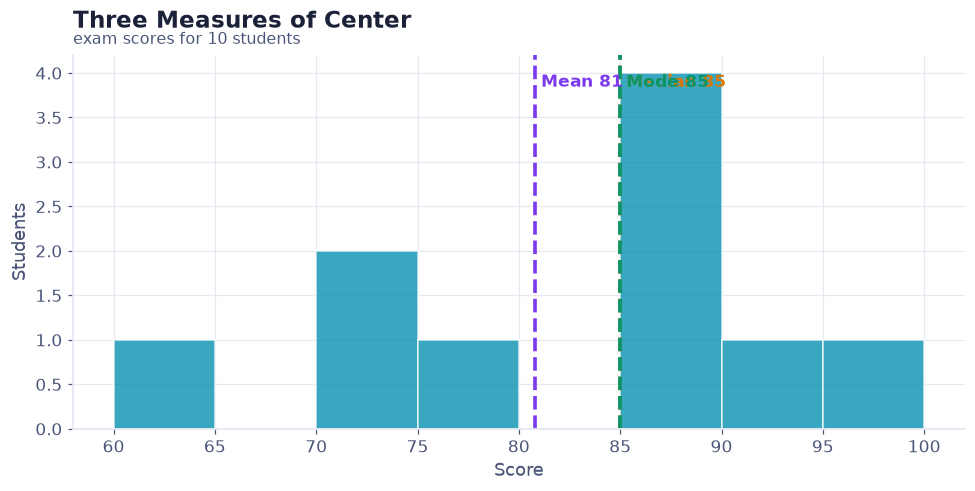

In [3]:
fig, ax = plt.subplots(figsize=(9,4.6))
ax.hist(scores, bins=range(60,101,5), color=CYAN, alpha=0.8, edgecolor="white")
for v, lab, c in [(mean,"Mean",PURPLE),(median,"Median",AMBER),(mode,"Mode",GREEN)]:
    ax.axvline(v, color=c, ls="--", lw=2.4)
    ax.text(v, ax.get_ylim()[1]*0.95, f" {lab} {v:.0f}", color=c, fontweight="bold", va="top")
titlecard(ax, "Three Measures of Center", "exam scores for 10 students")
ax.set_xlabel("Score"); ax.set_ylabel("Students")
plt.tight_layout(); plt.show()

<div style="background:#f0e9fe;border-left:5px solid #7c3aed;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#7c3aed;letter-spacing:1px">DEMO 2 · THE OUTLIER TEST</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">💰 Why the median resists extremes</div>
<div style="color:#4a5578;margin-top:6px">Add one billionaire to a room and the mean salary explodes, but the median barely flinches. This is why incomes are usually reported as medians.</div>
</div>

In [4]:
salaries = pd.Series([42, 45, 48, 50, 47, 44, 46])   # $thousands, an ordinary team
print(f"Team only  -> mean ${salaries.mean():.1f}k,  median ${salaries.median():.1f}k")

# The CEO walks in earning $1,000k
with_ceo = pd.concat([salaries, pd.Series([1000])], ignore_index=True)
print(f"+ the CEO  -> mean ${with_ceo.mean():.1f}k,  median ${with_ceo.median():.1f}k")
print("\nOne outlier dragged the MEAN up by hundreds; the MEDIAN moved by $1k.")

Team only  -> mean $46.0k,  median $46.0k
+ the CEO  -> mean $165.2k,  median $46.5k

One outlier dragged the MEAN up by hundreds; the MEDIAN moved by $1k.


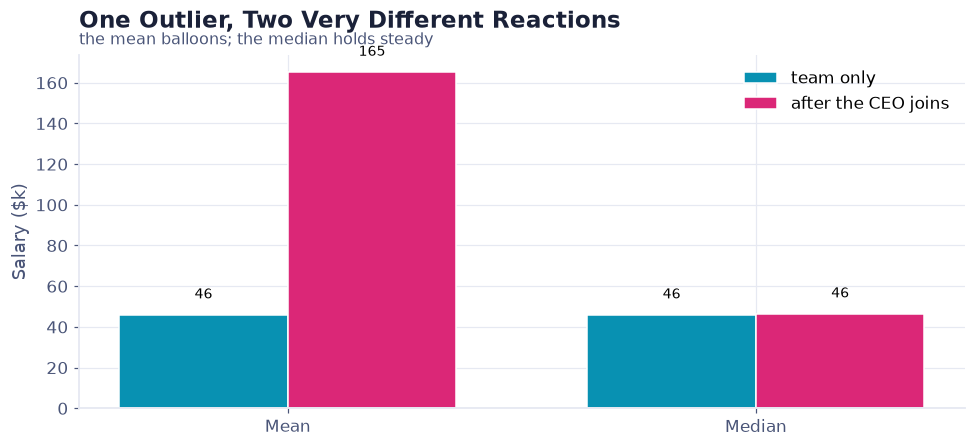

In [5]:
fig, ax = plt.subplots(figsize=(9,4.2))
labels = ["Mean", "Median"]
before = [salaries.mean(), salaries.median()]
after  = [with_ceo.mean(), with_ceo.median()]
x = np.arange(2); w = 0.36
ax.bar(x-w/2, before, w, color=CYAN, label="team only", edgecolor="white")
ax.bar(x+w/2, after,  w, color=PINK, label="after the CEO joins", edgecolor="white")
for xi, b, a in zip(x, before, after):
    ax.text(xi-w/2, b+8, f"{b:.0f}", ha="center", fontsize=9)
    ax.text(xi+w/2, a+8, f"{a:.0f}", ha="center", fontsize=9)
titlecard(ax, "One Outlier, Two Very Different Reactions", "the mean balloons; the median holds steady")
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylabel("Salary ($k)"); ax.legend()
plt.tight_layout(); plt.show()

**Rule of thumb:** when the data has outliers or is skewed, report the **median**. The mean is best for roughly symmetric data with no extreme values.

<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#d97706;letter-spacing:1px">DEMO 3 · SKEW & THE AVERAGE</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">↗️ How skew pulls the mean away from the median</div>
<div style="color:#4a5578;margin-top:6px">In a symmetric distribution mean = median. A long right tail drags the mean above the median; a long left tail drags it below.</div>
</div>

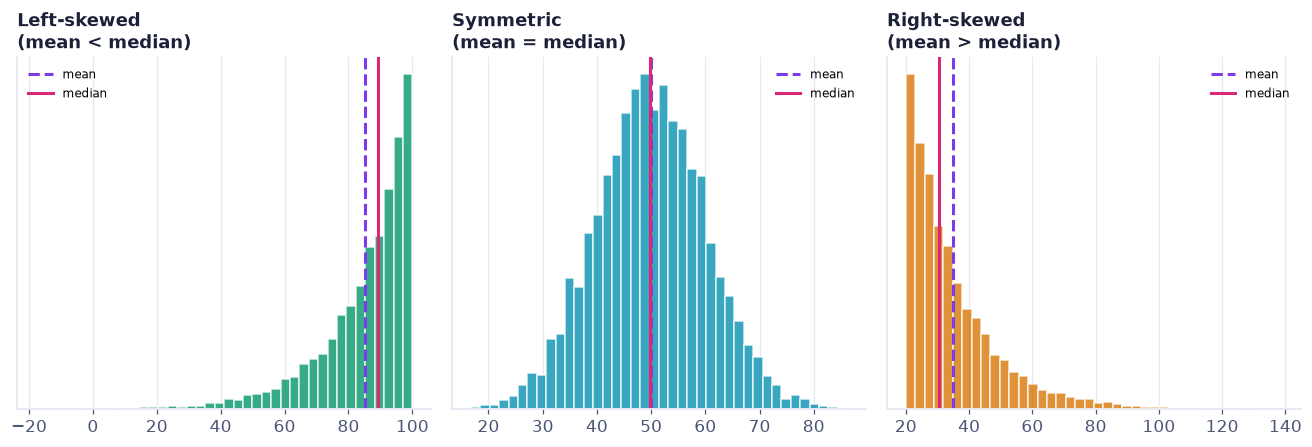

Right-skew: mean 34.9 > median 30.5
Left-skew : mean 85.1 < median 89.4


In [6]:
symmetric  = rng.normal(50, 10, 5000)
right_skew = rng.exponential(15, 5000) + 20     # long tail to the right (like incomes)
left_skew  = 100 - rng.exponential(15, 5000)    # long tail to the left (like easy-exam scores)

fig, axes = plt.subplots(1, 3, figsize=(12,4.2))
for ax, data, title, color in [
        (axes[0], left_skew,  "Left-skewed\n(mean < median)",  GREEN),
        (axes[1], symmetric,  "Symmetric\n(mean = median)",     CYAN),
        (axes[2], right_skew, "Right-skewed\n(mean > median)",  AMBER)]:
    ax.hist(data, bins=40, color=color, alpha=0.8, edgecolor="white")
    ax.axvline(np.mean(data),   color=PURPLE, ls="--", lw=2, label="mean")
    ax.axvline(np.median(data), color=PINK,   ls="-",  lw=2, label="median")
    ax.set_title(title, loc="left", fontsize=12, fontweight="bold", color=INK)
    ax.set_yticks([]); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"Right-skew: mean {right_skew.mean():.1f} > median {np.median(right_skew):.1f}")
print(f"Left-skew : mean {left_skew.mean():.1f} < median {np.median(left_skew):.1f}")

**The tail pulls the mean.** That is why "average income" (mean) usually looks higher than what a typical person earns (median): a few very high earners stretch the right tail.

<div style="background:#e3f6ee;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#059669;letter-spacing:1px">DEMO 4 · AM ≥ GM ≥ HM</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">📐 Three kinds of mean, and when each one fits</div>
<div style="color:#4a5578;margin-top:6px">The arithmetic mean is the everyday average. The geometric mean fits growth rates and percentages. The harmonic mean fits rates like speed. For positive data, AM ≥ GM ≥ HM, always.</div>
</div>

In [7]:
data = np.array([2, 4, 6, 8, 10])
n = len(data)
AM = data.mean()
GM = np.exp(np.mean(np.log(data)))      # geometric mean = nth root of the product
HM = n / np.sum(1/data)                 # harmonic mean = reciprocal of the mean of reciprocals
print(f"Arithmetic mean (AM) = {AM:.3f}")
print(f"Geometric  mean (GM) = {GM:.3f}")
print(f"Harmonic   mean (HM) = {HM:.3f}")
print(f"Check the ordering   : AM ≥ GM ≥ HM  ->  {AM:.2f} ≥ {GM:.2f} ≥ {HM:.2f}  ✔")

Arithmetic mean (AM) = 6.000
Geometric  mean (GM) = 5.210
Harmonic   mean (HM) = 4.380
Check the ordering   : AM ≥ GM ≥ HM  ->  6.00 ≥ 5.21 ≥ 4.38  ✔


In [8]:
# Real use 1: average GROWTH RATE -> geometric mean
# An investment grows 10%, then 50%, then -20% over three years.
factors = np.array([1.10, 1.50, 0.80])
avg_growth = np.exp(np.mean(np.log(factors))) - 1
print(f"Average annual growth (GM) = {avg_growth*100:.1f}%   (NOT the arithmetic 13.3%)")

# Real use 2: average SPEED over equal distances -> harmonic mean
# Drive 60 km at 30 km/h, then 60 km at 60 km/h.
speeds = np.array([30, 60])
avg_speed = len(speeds) / np.sum(1/speeds)
print(f"Average speed (HM)         = {avg_speed:.1f} km/h   (NOT the arithmetic 45 km/h)")

Average annual growth (GM) = 9.7%   (NOT the arithmetic 13.3%)
Average speed (HM)         = 40.0 km/h   (NOT the arithmetic 45 km/h)


**Pick the mean that matches the question.** Adding things up? Arithmetic. Compounding rates or percentages? Geometric. Averaging speeds or rates over equal distances? Harmonic.

<div style="background:#e6effe;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#2563eb;letter-spacing:1px">DEMO 5 · MEAN OF GROUPED DATA</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">📊 Averaging a frequency table</div>
<div style="color:#4a5578;margin-top:6px">Sometimes you only have counts per range, not the raw values. Estimate the mean using each class midpoint, weighted by how many fall in it.</div>
</div>

In [9]:
# Ages grouped into 10-year bins, with how many people fall in each
midpoints   = np.array([5, 15, 25, 35, 45, 55])
frequencies = np.array([3,  7, 12, 10,  6,  2])

grouped_mean = np.sum(midpoints * frequencies) / np.sum(frequencies)
print(f"Total people     : {frequencies.sum()}")
print(f"Estimated mean age: {grouped_mean:.1f} years")
print("Formula: mean ≈ Σ(midpoint × frequency) / Σ(frequency)")

Total people     : 40
Estimated mean age: 28.8 years
Formula: mean ≈ Σ(midpoint × frequency) / Σ(frequency)


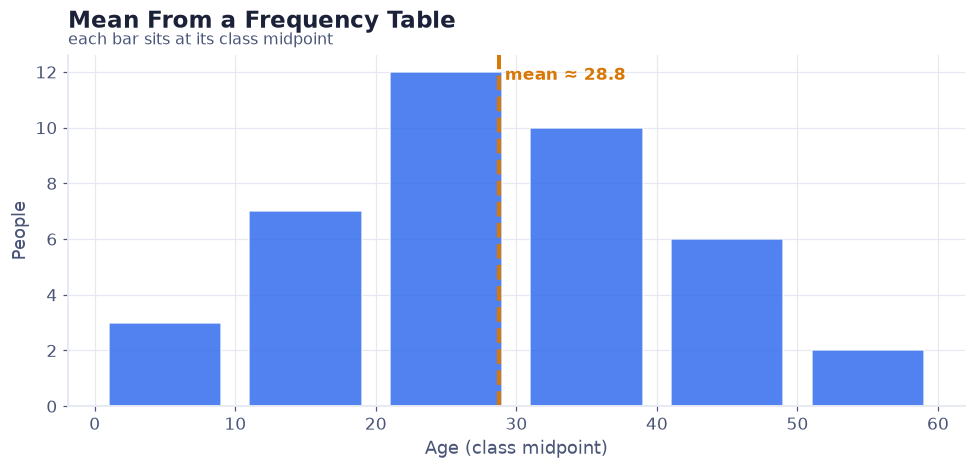

In [10]:
fig, ax = plt.subplots(figsize=(9,4.4))
ax.bar(midpoints, frequencies, width=8, color=BLUE, alpha=0.8, edgecolor="white")
ax.axvline(grouped_mean, color=AMBER, ls="--", lw=2.6)
ax.text(grouped_mean, ax.get_ylim()[1]*0.93, f" mean ≈ {grouped_mean:.1f}", color=AMBER, fontweight="bold")
titlecard(ax, "Mean From a Frequency Table", "each bar sits at its class midpoint")
ax.set_xlabel("Age (class midpoint)"); ax.set_ylabel("People")
plt.tight_layout(); plt.show()

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:24px 28px;font-family:Inter,sans-serif;box-shadow:0 8px 30px rgba(20,30,80,0.05)">
<div style="font-size:20px;font-weight:800;color:#1a2138">🎓 Recap</div>
<ul style="color:#4a5578;line-height:1.9;margin-top:10px">
<li><b>Mean, median, mode</b> are three ways to name the typical value.</li>
<li>The <b>median resists outliers</b>; the mean does not, so report the median for skewed data.</li>
<li><b>Skew</b> pulls the mean toward the long tail, away from the median.</li>
<li><b>AM ≥ GM ≥ HM</b>: use the arithmetic mean for sums, the geometric for growth, the harmonic for rates.</li>
<li>For <b>grouped data</b>, estimate the mean with class midpoints weighted by frequency.</li>
</ul>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:18px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>